---
---
# MBA - 2026
## Dirección Financiera

### Profesor Fernando Díaz Hurtado.
---


# 🇺🇸 Instrumentos financieros norteamericanos

En esta sección trabajaremos con información financiera del mercado estadounidense, incluyendo **índices accionarios** y **bonos del Tesoro de Estados Unidos**.

## 📈 Índices accionarios disponibles

Un **índice accionario** es un indicador que resume el comportamiento de un grupo de acciones. Su valor se construye a partir de los precios o de la capitalización bursátil de las empresas que lo componen.

Los índices permiten observar la evolución general de un mercado o de un segmento específico, por ejemplo, empresas grandes, medianas o pequeñas. También se utilizan como **benchmarks**, es decir, como referencias para comparar el desempeño de una cartera de inversión.

El paquete **tidyquant** permite consultar la composición de distintos índices mediante la función `tq_index()`.

Los índices disponibles son:

* **`DOW` — Dow Jones Industrial Average:** reúne 30 grandes empresas estadounidenses. Es uno de los indicadores bursátiles más tradicionales y ampliamente difundidos.

* **`DOWGLOBAL` — Dow Jones Global Index:** representa empresas de distintos países y permite observar el desempeño general del mercado accionario global.

* **`SP400` — S&P MidCap 400:** incluye empresas estadounidenses de mediana capitalización. Permite analizar el segmento intermedio entre las grandes empresas del S&P 500 y las empresas pequeñas del S&P 600.

* **`SP500` — S&P 500:** agrupa aproximadamente 500 grandes empresas estadounidenses. Es uno de los principales indicadores del mercado accionario de Estados Unidos y suele utilizarse como aproximación del **portafolio de mercado**.

* **`SP600` — S&P SmallCap 600:** incluye empresas estadounidenses de menor capitalización bursátil y permite estudiar el comportamiento del segmento de empresas pequeñas o *small caps*.

> 💡 **Importancia:** los índices accionarios permiten medir el desempeño de distintos segmentos del mercado, comparar inversiones y construir referencias para evaluar una cartera.



## 🏛️ Bonos del Tesoro de Estados Unidos

Los **bonos del Tesoro de Estados Unidos** son instrumentos de deuda emitidos por el gobierno federal. Debido a su elevada liquidez y bajo riesgo de incumplimiento, sus rendimientos suelen utilizarse como referencia para las tasas de interés del mercado y como aproximación de la **tasa libre de riesgo**.

Los principales instrumentos son:

* **Treasury Bills (T-Bills):** instrumentos de corto plazo con vencimientos de **4, 8, 13, 17, 26 y 52 semanas**. Se venden con descuento respecto de su valor nominal y no pagan cupones periódicos. La rentabilidad del inversionista corresponde a la diferencia entre el precio de compra y el valor recibido al vencimiento.

* **Treasury Notes (T-Notes):** instrumentos de mediano plazo con vencimientos de **2, 3, 5, 7 y 10 años**. Pagan intereses mediante cupones semestrales y devuelven el principal al vencimiento.

* **Treasury Bonds (T-Bonds):** instrumentos de largo plazo con vencimientos de **20 y 30 años**. También pagan cupones semestrales y reembolsan el valor principal al vencimiento.

* **Treasury Inflation-Protected Securities (TIPS):** instrumentos cuyo principal se ajusta de acuerdo con la inflación. Se emiten con vencimientos de **5, 10 y 30 años** y están diseñados para proteger el poder adquisitivo del inversionista.

* **Floating Rate Notes (FRNs):** instrumentos con vencimiento de **2 años** cuya tasa de interés es variable. El cupón se ajusta periódicamente de acuerdo con una tasa de referencia de corto plazo.

> 💡 **Importancia:** los rendimientos de los bonos del Tesoro permiten analizar la estructura temporal de tasas de interés, estimar la tasa libre de riesgo, valorar activos financieros y estudiar las expectativas del mercado sobre inflación, crecimiento económico y política monetaria.



## 📦 Cargando las librerías

Antes de comenzar el análisis, cargaremos los paquetes de **R** que utilizaremos a lo largo del notebook:

* **`tidyquant`**: descarga y manipulación de datos financieros.
* **`dplyr`**: transformación y organización de bases de datos.
* **`ggplot2`**: construcción de gráficos.
* **`lubridate`**: manejo de fechas y períodos de tiempo.

> 💡 Las librerías deben instalarse una sola vez, pero deben cargarse cada vez que se inicia una nueva sesión de R.


In [25]:
install.packages(c("tidyquant", "dplyr", "ggplot2", "lubridate"), quiet = TRUE)

In [1]:
suppressWarnings(suppressPackageStartupMessages({
  library(tidyquant)
  library(dplyr)
  library(ggplot2)
  library(lubridate)
}))

---
# 📊 El paquete `tidyquant`

<p align="center">
  <a href="https://business-science.github.io/tidyquant/" target="_blank">
    <img src="https://business-science.github.io/tidyquant/logo.png"
         alt="Logo de tidyquant"
         width="220">
  </a>
</p>

[`tidyquant`](https://business-science.github.io/tidyquant/) es un paquete de **R** diseñado para facilitar la obtención, manipulación, visualización y análisis de datos financieros y series temporales dentro del flujo de trabajo de `tidyverse`.

El paquete integra herramientas provenientes de librerías especializadas como `quantmod`, `xts`, `zoo`, `TTR` y `PerformanceAnalytics`, pero permite trabajar con ellas utilizando estructuras de datos y funciones compatibles con `dplyr`, `tidyr` y `ggplot2`.

Entre sus principales funcionalidades se encuentran:

* 🌐 **Descargar datos financieros y económicos** mediante `tq_get()`.
* 🏢 **Consultar las empresas que componen índices bursátiles** mediante `tq_index()`.
* 🔄 **Transformar series financieras** mediante `tq_mutate()` y `tq_transmute()`.
* 📈 **Construir visualizaciones financieras** utilizando `ggplot2`.
* 💼 **Analizar retornos y carteras de inversión** mediante funciones de desempeño y agregación de portafolios.

> 🔗 **Documentación oficial:** [business-science.github.io/tidyquant](https://business-science.github.io/tidyquant/)


## 📈 Índices accionarios disponibles


In [27]:
# Esta función muestra los índices accionarios disponibles 
# para consultar mediante tq_index().

tq_index_options()

[1] "DOW"       "DOWGLOBAL" "SP400"     "SP500"     "SP600"

---
# 📈 Índice S&P 500

<p align="center">
  <a href="https://en.wikipedia.org/wiki/S%26P_500" target="_blank">
    <img src="https://upload.wikimedia.org/wikipedia/commons/c/c4/S%26P_Dow_Jones_Indices_logo.svg"
         alt="S&P Dow Jones Indices logo" width="300"/>
  </a>
</p>

El **S&P 500** es un índice accionario diseñado para medir el desempeño de las empresas de gran capitalización del mercado estadounidense. Incluye 500 compañías líderes —aunque puede contener más de 500 acciones debido a empresas con distintas clases accionarias— y cubre aproximadamente el **80 % de la capitalización bursátil disponible** de Estados Unidos. Por esta razón, se considera una de las principales referencias del mercado accionario estadounidense.

## 🏛️ Administración y selección de empresas

El índice es elaborado y administrado por **S&P Dow Jones Indices**. Su composición no se determina simplemente seleccionando las 500 empresas más grandes: un comité evalúa criterios de elegibilidad relacionados con capitalización bursátil, liquidez, flotación pública, domicilio, cotización en mercados estadounidenses, viabilidad financiera y representación sectorial.

La composición se revisa continuamente, mientras que sus ponderaciones y acciones en circulación se actualizan en los rebalanceos trimestrales de **marzo, junio, septiembre y diciembre**.

## ⚖️ ¿Es un índice *value weighted*?

Sí, en el sentido tradicional de que las empresas se ponderan según su **valor de mercado**. Sin embargo, la denominación técnicamente correcta es:

> **Índice ponderado por capitalización bursátil ajustada por flotación libre.**

Asigna mayor peso a las empresas con mayor capitalización bursátil disponible para inversión.

La capitalización bursátil ajustada (***Float-adjusted Market Capitalization***) de la empresa $i$ se calcula como:

$$
FMC_i=P_i\times Q_i\times IWF_i
$$

donde:

* $P_i$ es el precio de la acción;
* $Q_i$ es el número total de acciones en circulación;
* $IWF_i$ es el *Investable Weight Factor*, que representa la proporción de acciones considerada disponible para los inversionistas.

El peso de cada empresa es:

$$
w_i=
\frac{FMC_i}
{\sum_{j=1}^{N}FMC_j}
$$

Por lo tanto, una empresa con mayor capitalización ajustada por flotación libre tiene una mayor incidencia sobre el retorno del índice.

## 🌊 ¿Qué es el *free float*?

El **free float** o flotación libre corresponde a la proporción de acciones que se encuentra efectivamente disponible para negociación pública.

Se excluyen, entre otras, participaciones estratégicas o bloques de control mantenidos por:

* fundadores y altos ejecutivos;
* gobiernos y organismos públicos;
* empresas matrices o accionistas controladores;
* inversionistas institucionales;
* fundaciones corporativas;
* otros propietarios estratégicos cuyas acciones no se negocian regularmente.

El ajuste por flotación busca que la ponderación de cada compañía refleje mejor la cantidad de acciones que los inversionistas realmente pueden comprar y vender.

### 📊 ¿Cuál es el *free float* promedio?

No existe en la ficha pública del índice una cifra oficial única para el **free float promedio del S&P 500**. Además, este valor cambia cuando varían las estructuras de propiedad, las acciones en circulación o los componentes del índice.

> ⚠️ No debe inferirse el *free float* promedio a partir del peso de las empresas en el índice, porque dicho peso combina precio, acciones en circulación y flotación disponible.

En cualquier caso, el free float promedio del S&P 500 es alto, estimándose cercano al 90%.

## 📏 Concentración del índice

Debido a su metodología de ponderación, las empresas más grandes tienen una influencia considerable. Al **29 de mayo de 2026**, el componente de mayor peso representaba aproximadamente **7,5 %** del índice y los diez componentes principales concentraban alrededor de **36,4 %**. Estas cifras cambian con los precios de mercado.

## 📈 ¿Por qué es importante?

El S&P 500 se utiliza como:

* indicador del desempeño de las grandes empresas estadounidenses;
* referencia o *benchmark* para evaluar fondos y carteras;
* base para fondos indexados, ETF, futuros y opciones;
* aproximación empírica del portafolio de mercado;
* referencia para estimar retornos exigidos y primas de riesgo.

### 🧮 El S&P 500 como benchmark en el CAPM

El **Capital Asset Pricing Model (CAPM)** establece que:

$$
E(R_i)=
R_f+
\beta_i
\left[
E(R_M)-R_f
\right]
$$

donde:

* $R_f$ es la tasa libre de riesgo;
* $E(R_M)-R_f$ es la prima de riesgo del mercado;
* $\beta_i$ mide la sensibilidad del activo frente al mercado.

La beta se calcula como:

$$
\beta_i=
\frac{\operatorname{Cov}(R_i,R_M)}
{\operatorname{Var}(R_M)}
$$

En teoría, $R_M$ debería corresponder al retorno del **portafolio de mercado**, compuesto por todos los activos riesgosos disponibles.

Como ese portafolio no es directamente observable, el S&P 500 se utiliza habitualmente como una aproximación porque posee amplia cobertura del mercado estadounidense, elevada liquidez, diversificación sectorial y una extensa historia de datos.

> ⚠️ **Precisión conceptual:** el S&P 500 no es el portafolio de mercado teórico del CAPM. No incluye empresas pequeñas fuera del índice, acciones extranjeras, bonos, bienes raíces ni otros activos riesgosos.

### 💻 Información del índice en `tidyquant`

La composición del S&P 500 puede obtenerse mediante:

```r
sp500 <- tq_index("SP500")
```

El objeto contiene información sobre las empresas que componen el índice, incluyendo sus símbolos bursátiles, nombres, sectores y ponderaciones disponibles en la fuente utilizada por `tidyquant`.


In [33]:
sp500 <- suppressMessages(tq_index('SP500'))

top_n <- 15

sp500_top <- sp500 |>
  arrange(desc(weight)) |>
  slice_head(n = top_n) |>
  transmute(
    `#` = row_number(),
    Símbolo = symbol,
    Empresa = company,
    `Peso (%)` = round(weight * 100, 2)
  )

suppressPackageStartupMessages(library(knitr))
suppressPackageStartupMessages(library(IRdisplay))

display_html(as.character(
  kable(sp500_top, format = "html", align = c("c", "l", "l", "r"))
))

cat(sprintf(
  "A la fecha, las %d empresas de mayor peso concentran %.1f%% del índice (%d componentes en total).",
  top_n, sum(sp500_top[["Peso (%)"]]), nrow(sp500)
))

#,Símbolo,Empresa,Peso (%)
1,NVDA,NVIDIA CORP,7.89
2,AAPL,APPLE INC,7.37
3,MSFT,MICROSOFT CORP,4.50
4,AMZN,AMAZON.COM INC,3.82
5,GOOGL,ALPHABET INC CL A,3.33
6,AVGO,BROADCOM INC,2.86
7,GOOG,ALPHABET INC CL C,2.68
8,META,META PLATFORMS INC CLASS A,2.29
9,TSLA,TESLA INC,1.70
10,MU,MICRON TECHNOLOGY INC,1.56


A la fecha, las 15 empresas de mayor peso concentran 44.4% del índice (505 componentes en total).

## 📈 Evolución del S&P 500 a través del tiempo

Una vez obtenida la composición del índice, podemos analizar su comportamiento histórico mediante la serie de precios del **S&P 500**.

Este análisis permite observar:

* la tendencia de largo plazo del mercado accionario estadounidense;
* períodos de expansión y contracción;
* episodios de alta volatilidad;
* caídas asociadas a crisis financieras o económicas;
* la recuperación posterior del mercado.

Para descargar la serie histórica de los últimos 30 años, utilizaremos la función `tq_get()` del paquete `tidyquant` y el símbolo bursátil **`^GSPC`**, empleado habitualmente para identificar al índice S&P 500 en Yahoo Finance.


> 💡 Es importante distinguir entre el **nivel del índice** y su **retorno**. El nivel muestra el valor acumulado del S&P 500 en cada fecha, mientras que el retorno mide su variación porcentual entre dos períodos.


In [2]:
# Set date range: last 30 years from today
start_date <- today() - years(30)
end_date <- today()

In [3]:
# Download SP500 index data
sp500_data <- tq_get("^GSPC", 
                     from = start_date, 
                     to = end_date)

In [31]:
suppressPackageStartupMessages(library(knitr))
suppressPackageStartupMessages(library(IRdisplay))

display_html(as.character(
  kable(head(sp500_data), format = "html", digits = 2, format.args = list(big.mark = ","))
))

symbol,date,open,high,low,close,volume,adjusted
^GSPC,1996-07-16,629.80,631.99,605.88,628.37,"682,980,000",628.37
^GSPC,1996-07-17,628.37,636.61,628.37,634.07,"513,830,000",634.07
^GSPC,1996-07-18,634.07,644.44,633.29,643.56,"474,460,000",643.56
^GSPC,1996-07-19,643.51,643.51,635.50,638.73,"408,070,000",638.73
^GSPC,1996-07-22,638.73,638.73,630.38,633.77,"327,300,000",633.77
^GSPC,1996-07-23,633.79,637.70,625.65,626.87,"421,900,000",626.87


Grafiquemos el precio de cierre, ajustado por dividendos y splits:

Utilizamos el precio de cierre **ajustado** (`adjusted`) en lugar del precio de cierre bruto (`close`) porque este último puede distorsionar el retorno real del activo:

* **Splits (divisiones de acciones):** si una empresa hace un split 2×1, el precio bruto cae a la mitad de un día para otro, aunque el valor total en manos del inversionista no cambia. El precio ajustado reescala la serie histórica para que se mantenga continua.
* **Dividendos:** en la fecha ex-dividendo, el precio bruto cae aproximadamente en el monto del dividendo pagado —ese valor no se perdió, simplemente se distribuyó como efectivo—. El precio ajustado corrige esta caída, reflejando el retorno total (variación de precio + dividendos reinvertidos).

> 💡 En este caso particular, `^GSPC` es un **índice de precios**, no una acción individual: no tiene splits ni dividendos propios, por lo que `adjusted` y `close` suelen ser prácticamente idénticos aquí. Aun así, usamos `adjusted` como buena práctica, ya que el mismo patrón (`tq_get()` + retornos sobre `adjusted`) se reutiliza más adelante con acciones individuales que sí pagan dividendos, donde la diferencia sí es relevante.

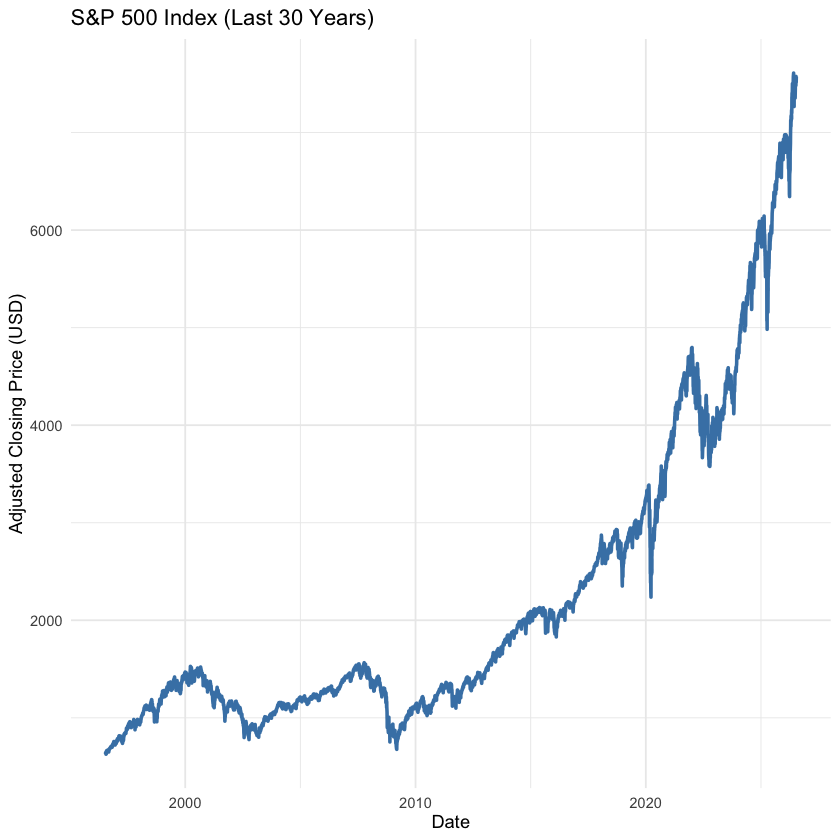

In [32]:
# Plot Adjusted Close Price
sp500_data |>
  ggplot(aes(x = date, y = adjusted)) +
  geom_line(color = "steelblue", linewidth = 1) +
  labs(
    title = "S&P 500 Index (Last 30 Years)",
    x = "Date",
    y = "Adjusted Closing Price (USD)"
  ) +
  theme_minimal()

Marquemos en el gráfico algunas de las principales caídas de mercado de los últimos 30 años, junto con el retorno diario registrado en el peor día de cada episodio:

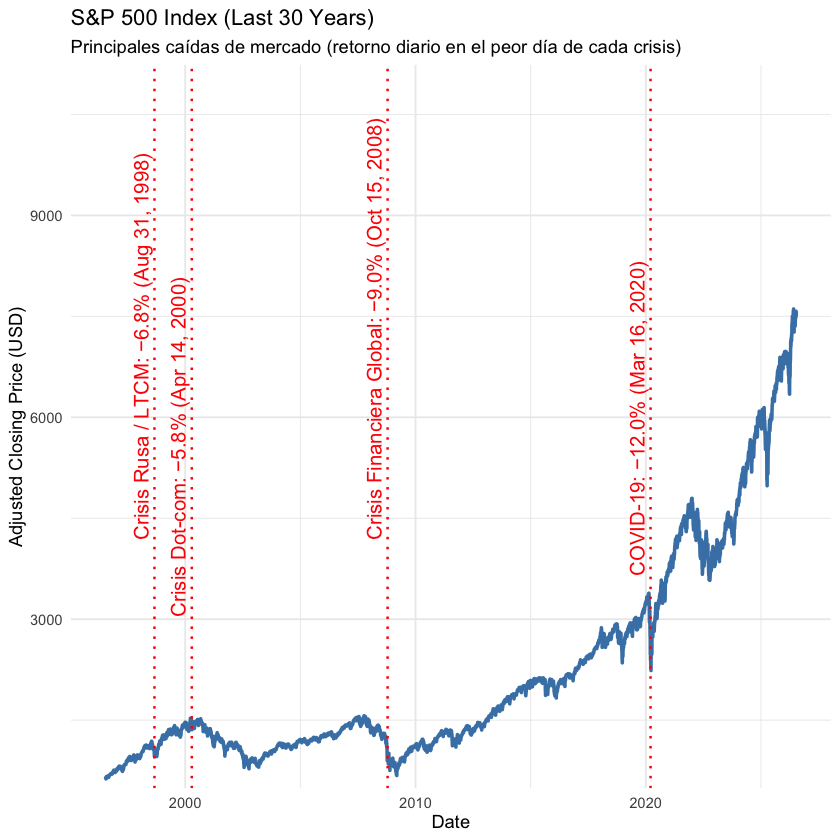

In [4]:
# Principales caídas de mercado (peor retorno diario dentro de cada crisis)
crash_events <- tibble(
  date  = as.Date(c("1998-08-31", "2000-04-14", "2008-10-15", "2020-03-16")),
  event = c("Crisis Rusa / LTCM", "Crisis Dot-com", "Crisis Financiera Global", "COVID-19"),
  ret   = c(-0.0680, -0.0583, -0.0903, -0.1198),
  y_frac = c(0.55, 0.40, 0.55, 0.48)
)

y_top <- max(sp500_data$adjusted, na.rm = TRUE)

crash_events <- crash_events |>
  mutate(
    label = sprintf("%s: −%.1f%% (%s)", event, abs(ret) * 100, format(date, "%b %d, %Y")),
    y_pos = y_frac * y_top
  )

sp500_data |>
  ggplot(aes(x = date, y = adjusted)) +
  geom_line(color = "steelblue", linewidth = 1) +
  geom_vline(data = crash_events, aes(xintercept = date),
             color = "red", linetype = "dotted", linewidth = 0.7) +
  geom_text(data = crash_events,
            aes(x = date, y = y_pos, label = label),
            color = "red", angle = 90, hjust = 0, vjust = -0.4, size = 4.3) +
  scale_y_continuous(expand = expansion(mult = c(0.02, 0.52))) +
  labs(
    title = "S&P 500 Index (Last 30 Years)",
    subtitle = "Principales caídas de mercado (retorno diario en el peor día de cada crisis)",
    x = "Date",
    y = "Adjusted Closing Price (USD)"
  ) +
  theme_minimal()

---
# Diferentes Activos y Clases de Activos

Ahora, para el mismo periodo de tiempo, descargaremos el DOW, el SP600 y las series del Tesoro a 10 años con vencimiento constante. 

Tanto el S&P 500, el S&P 600 como el Dow Jones Industrial Average (DJIA o “el Dow”) pertenecen a la clase de **Renta Variable**, ya que están compuestos por acciones. Los bonos, por su parte, corresponden a la clase de **Renta Fija**.


### 📊 Diferencias entre el S&P 500, S&P 600 y el Dow

| Índice        | ¿Qué representa?                                                                 | Tipo de empresas             | Método de cálculo                      |
|---------------|----------------------------------------------------------------------------------|-------------------------------|----------------------------------------|
| **S&P 500**   | Las 500 mayores empresas de EE.UU. por capitalización bursátil.                  | **Large Cap** (grandes)       | Ponderado por capitalización de mercado |
| **S&P 600**   | 600 empresas pequeñas seleccionadas por su estabilidad y liquidez.               | **Small Cap** (pequeñas)      | Ponderado por capitalización de mercado |
| **Dow Jones** | 30 grandes empresas industriales líderes de EE.UU., muy conocidas.               | **Large Cap** (pero solo 30)  | **Ponderado por precio**, no por capitalización |


## Tendencias Temporales de los Diferentes Activos



* Representaremos todas las series en el mismo gráfico. 
* También normalizaremos el precio de cada instrumento a 100 en la primera fecha para que todos los gráficos empiecen en el mismo punto.
* Consideremos el período que se incia el año 2005.

symbol,date,open,high,low,close,volume,adjusted,label
<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
^TNX,2026-07-02,4.503,4.505,4.453,4.485,0,4.485,10Y Treasury
^TNX,2026-07-06,4.457,4.491,4.457,4.479,0,4.479,10Y Treasury
^TNX,2026-07-07,4.497,4.533,4.485,4.529,0,4.529,10Y Treasury
^TNX,2026-07-08,4.561,4.597,4.557,4.569,0,4.569,10Y Treasury
^TNX,2026-07-09,4.577,4.581,4.529,4.539,0,4.539,10Y Treasury
^TNX,2026-07-10,4.541,4.571,4.539,4.569,0,4.569,10Y Treasury


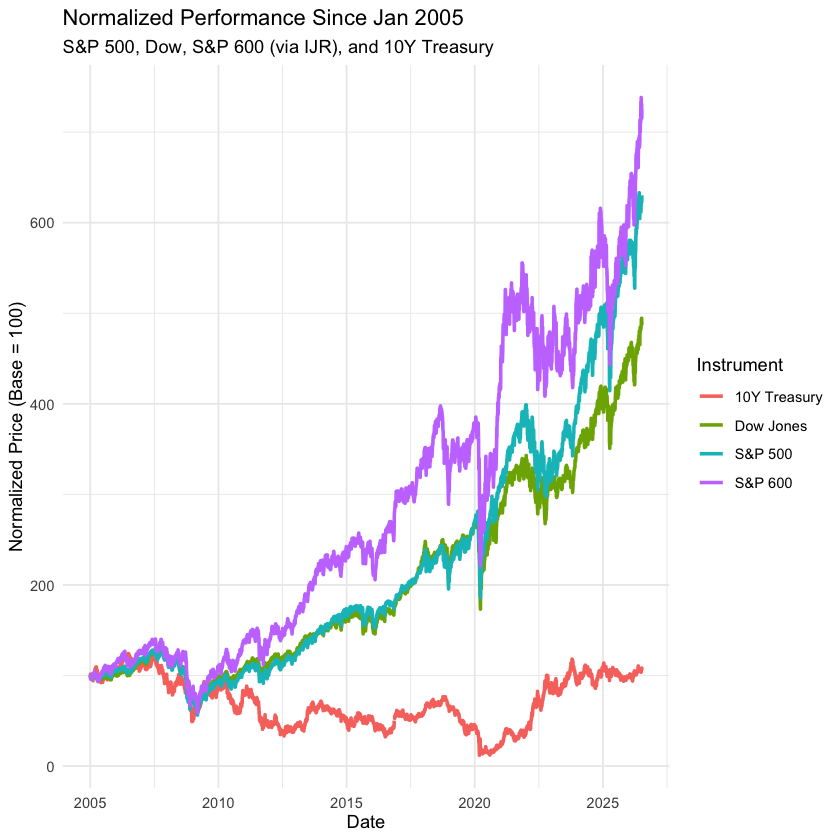

In [9]:

# Tickers
tickers <- c("^GSPC", "^DJI", "IJR", "^TNX")

# Human-readable labels
labels <- c("^GSPC" = "S&P 500",
            "^DJI" = "Dow Jones",
            "IJR" = "S&P 600",
            "^TNX" = "10Y Treasury")

# Set custom date range
start_date <- as.Date("2005-01-01")
end_date <- today()

# Download data
market_data <- tq_get(tickers,
                      from = start_date,
                      to = end_date,
                      get = "stock.prices")

# Add labels
market_data <- market_data |>
  mutate(label = labels[symbol])

# Normalize to 100 at start date
normalized_data <- market_data |>
  group_by(label) |>
  arrange(date) |>
  mutate(
    base_value = first(adjusted),
    norm_price = adjusted / base_value * 100
  ) |>
  ungroup()

# Plot
ggplot(normalized_data, aes(x = date, y = norm_price, color = label)) +
  geom_line(linewidth = 1) +
  labs(
    title = "Normalized Performance Since Jan 2005",
    subtitle = "S&P 500, Dow, S&P 600 (via IJR), and 10Y Treasury",
    x = "Date",
    y = "Normalized Price (Base = 100)",
    color = "Instrument"
  ) +
  theme_minimal()

tail(market_data)


OK. Nótese que la serie de los bonos del tesoro está espresada en puntos porcentuales. Podemos calcular un precio aproximado:

$$
\text{Price}_t = \frac{100}{(1 + r_t)^{10}}
$$

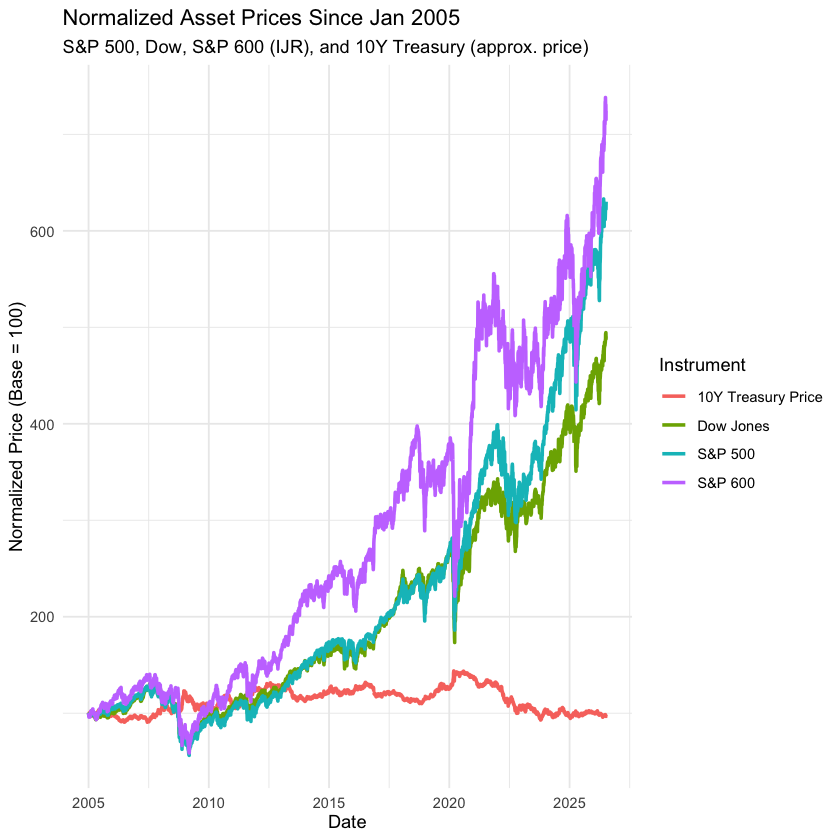

In [10]:
# Tickers
tickers <- c("^GSPC", "^DJI", "IJR", "^TNX")

labels <- c("^GSPC" = "S&P 500",
            "^DJI" = "Dow Jones",
            "IJR" = "S&P 600",
            "^TNX" = "10Y Treasury Price")

# Dates
start_date <- as.Date("2005-01-01")
end_date <- today()

# Download
market_data <- tq_get(tickers,
                      from = start_date,
                      to = end_date,
                      get = "stock.prices")

# Convert TNX yield to bond price
bond_price_data <- market_data |>
  filter(symbol == "^TNX") |>
  mutate(
    label = labels[symbol],  # assign label before changing symbol
    adjusted = 100 / (1 + adjusted / 100)^10,
    symbol = "10Y Treasury Price"  # change symbol last
  )

# Replace TNX data with computed prices
equity_data <- market_data |>
  filter(symbol != "^TNX") |>
  mutate(label = labels[symbol])

# Combine
full_data <- bind_rows(equity_data, bond_price_data)

# Normalize
normalized_data <- full_data |>
  group_by(label) |>
  arrange(date) |>
  mutate(
    base_value = first(adjusted),
    norm_price = adjusted / base_value * 100
  ) |>
  ungroup()

# Plot
ggplot(normalized_data, aes(x = date, y = norm_price, color = label)) +
  geom_line(linewidth = 1) +
  labs(
    title = "Normalized Asset Prices Since Jan 2005",
    subtitle = "S&P 500, Dow, S&P 600 (IJR), and 10Y Treasury (approx. price)",
    x = "Date",
    y = "Normalized Price (Base = 100)",
    color = "Instrument"
  ) +
  theme_minimal()


# Tendencias

## Tendencias Lineales

Agreguemos una tendencia a cada uno de estos activos:

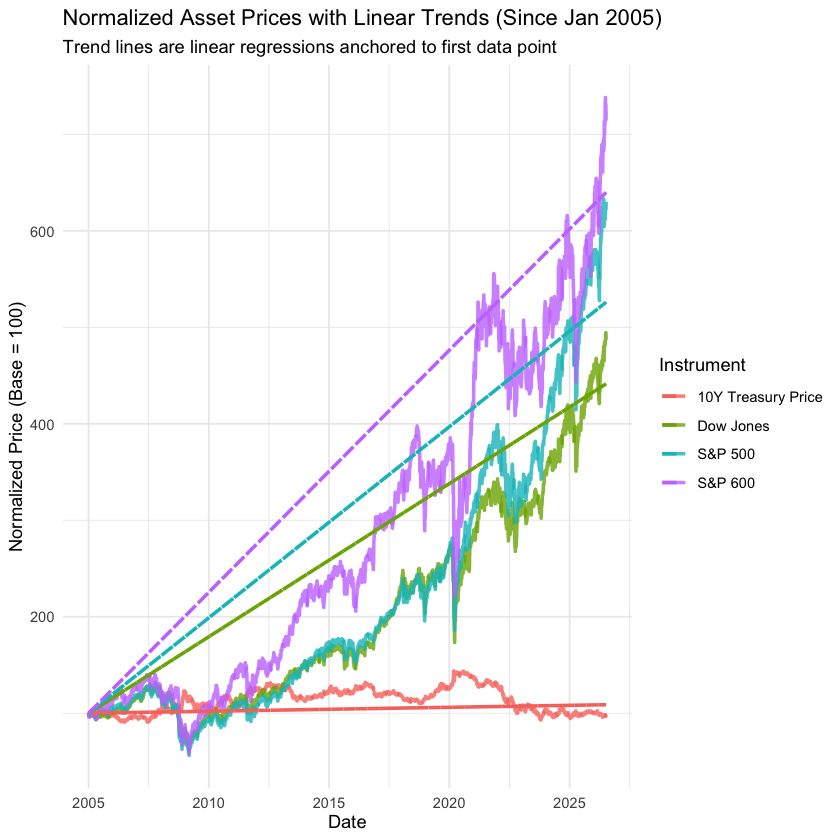

In [11]:
suppressWarnings(suppressPackageStartupMessages({
  library(tidyquant)
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(lubridate)
  library(purrr)
}))

# Tickers
tickers <- c("^GSPC", "^DJI", "IJR", "^TNX")

labels <- c("^GSPC" = "S&P 500",
            "^DJI" = "Dow Jones",
            "IJR" = "S&P 600",
            "^TNX" = "10Y Treasury Price")

# Dates
start_date <- as.Date("2005-01-01")
end_date <- today()

# Download
market_data <- tq_get(tickers,
                      from = start_date,
                      to = end_date,
                      get = "stock.prices")

# Convert TNX yield to bond price, assign label before changing symbol
bond_price_data <- market_data |>
  filter(symbol == "^TNX") |>
  mutate(
    label = labels[symbol],
    adjusted = 100 / (1 + adjusted / 100)^10,
    symbol = "10Y Treasury Price"
  )

# Other assets
equity_data <- market_data |>
  filter(symbol != "^TNX") |>
  mutate(label = labels[symbol])

# Combine data
full_data <- bind_rows(equity_data, bond_price_data)

# Normalize prices
normalized_data <- full_data |>
  group_by(label) |>
  arrange(date) |>
  mutate(
    base_value = first(adjusted),
    norm_price = adjusted / base_value * 100
  ) |>
  ungroup()

# Compute linear trends, anchored to first value
trend_data <- normalized_data |>
  group_by(label) |>
  mutate(days_since_start = as.numeric(date - min(date))) |>
  group_modify(~ {
    model <- lm(norm_price ~ days_since_start, data = .x)
    trend <- predict(model, newdata = .x)
    shift <- .x$norm_price[1] - trend[1]
    .x$trend <- trend + shift
    .x
  }) |>
  ungroup()

# Plot
ggplot(trend_data, aes(x = date)) +
  geom_line(aes(y = norm_price, color = label), linewidth = 1, alpha = 0.8) +
  geom_line(aes(y = trend, color = label), linetype = "dashed", linewidth = 1) +
  labs(
    title = "Normalized Asset Prices with Linear Trends (Since Jan 2005)",
    subtitle = "Trend lines are linear regressions anchored to first data point",
    x = "Date",
    y = "Normalized Price (Base = 100)",
    color = "Instrument"
  ) +
  theme_minimal()


## Retornos Históricos de cada Serie

In [12]:
# 1. Extract ^TNX yield series (not the computed price)
tnx_yield <- market_data |>
  filter(symbol == "^TNX") |>
  arrange(date) |>
  mutate(
    rate = adjusted / 100  # Convert from "TNX units" to decimal yield
  )

# 2. Compute average interest rate (annualized)
avg_yield <- tnx_yield |>
  summarise(
    avg_rate = mean(rate, na.rm = TRUE),
    avg_percent = round(avg_rate * 100, 2)
  ) |>
  mutate(label = "10Y Treasury Yield")

# 3. Compute average log returns for other series
average_returns <- normalized_data |>
  filter(label != "10Y Treasury Price") |>
  group_by(label) |>
  arrange(date) |>
  mutate(
    log_return = log(adjusted / lag(adjusted))
  ) |>
  summarise(
    avg_daily_log_return = mean(log_return, na.rm = TRUE),
    annual_log_return = avg_daily_log_return * 252,
    annual_percent = round(annual_log_return * 100, 2)
  ) |>
  ungroup() |>
  select(label, annual_percent)

# 4. Combine returns and yield
final_summary <- bind_rows(
  average_returns,
  avg_yield |> select(label, annual_percent = avg_percent)
)

print(final_summary)


# A tibble: 4 × 2
  label              annual_percent
  <chr>                       <dbl>
1 Dow Jones                    7.41
2 S&P 500                      8.57
3 S&P 600                      9.22
4 10Y Treasury Yield           3   


## Volatilidad de Cada Serie

Deberíamos observar que a maor retorno, existe mayor volatilidad.

In [13]:
# For equity 
returns_summary <- normalized_data |>
  filter(label != "10Y Treasury Price") |>
  group_by(label) |>
  arrange(date) |>
  mutate(
    log_return = log(adjusted / lag(adjusted))
  ) |>
  summarise(
    avg_daily_log_return = mean(log_return, na.rm = TRUE),
    sd_daily_log_return = sd(log_return, na.rm = TRUE),
    annual_return = avg_daily_log_return * 252,
    annual_volatility = sd_daily_log_return * sqrt(252),
    return_percent = round(annual_return * 100, 2),
    vol_percent = round(annual_volatility * 100, 2)
  ) |>
  select(label, return_percent, vol_percent)

# For 10Y Treasury yield (raw ^TNX)
tnx_stats <- market_data |>
  filter(symbol == "^TNX") |>
  mutate(
    yield = adjusted / 100  # Convert to decimal
  ) |>
  summarise(
    return_percent = round(mean(yield, na.rm = TRUE) * 100, 2),
    vol_percent = round(sd(yield, na.rm = TRUE) * 100, 2)
  ) |>
  mutate(label = "10Y Treasury Yield") |>
  select(label, return_percent, vol_percent)

# Combine everything and rank by risk, from lowest to highest volatility
final_summary <- bind_rows(returns_summary, tnx_stats) |>
  arrange(vol_percent) |>
  transmute(
    `Ranking Riesgo` = row_number(),
    Activo = label,
    `Retorno Anual (%)` = return_percent,
    `Volatilidad Anual (%)` = vol_percent
  )

# Display as a clean, publication-style HTML table, ordered from lowest to highest risk
suppressPackageStartupMessages(library(knitr))
suppressPackageStartupMessages(library(IRdisplay))

display_html(as.character(
  kable(final_summary, format = "html", align = c("c", "l", "r", "r"))
))

Ranking Riesgo,Activo,Retorno Anual (%),Volatilidad Anual (%)
1,10Y Treasury Yield,3.00,1.14
2,Dow Jones,7.41,18.00
3,S&P 500,8.57,19.08
4,S&P 600,9.22,23.44
